In [ ]:
import pandas as pd 
import numpy as np 
import torch
import torch.nn as nn 
import torch.optim as optim
from torch.utils.data import DataLoader,Dataset 
from torchvision.transforms import v2
from PIL import Image
import cv2 
import os 

In [ ]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

In [ ]:
from tokenizers import Tokenizer

tokenizer = Tokenizer.from_file("ocr_bpe_tokenizer.json")



In [ ]:
tokenizer.encode("<pad>").ids

[0]

In [ ]:
tokenizer.encode("Anthaltnic").ids

[789, 2176, 87, 2674]

In [ ]:
img1 =cv2.imread("handwritten-data/synthetic-data/certainly@08RvCt.png")

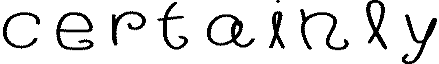

In [ ]:
Image.fromarray(cv2.resize(img1,(439,64)))

In [ ]:
img1.shape

(93, 439, 3)

In [ ]:
import torch.nn.functional as F

In [ ]:
chars = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

char_to_idx = {c: i for i, c in enumerate(chars)}
blank_idx = len(chars)  # 26

In [ ]:
char_to_idx["<bos>"] = len(char_to_idx)
char_to_idx["<eos>"] = len(char_to_idx)


In [ ]:
char_to_idx

{'A': 0,
 'B': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'G': 6,
 'H': 7,
 'I': 8,
 'J': 9,
 'K': 10,
 'L': 11,
 'M': 12,
 'N': 13,
 'O': 14,
 'P': 15,
 'Q': 16,
 'R': 17,
 'S': 18,
 'T': 19,
 'U': 20,
 'V': 21,
 'W': 22,
 'X': 23,
 'Y': 24,
 'Z': 25,
 '<bos>': 26,
 '<eos>': 27}

In [ ]:
pad_id = tokenizer.token_to_id("<pad>")
bos_id = tokenizer.token_to_id("<bos>")
eos_id = tokenizer.token_to_id("<eos>")
unk_id = tokenizer.token_to_id("<unk>")


In [ ]:
tokenizer.get_vocab_size()

10000

### we will use shape : (x,64),height:64,width: depends on batch 

In [ ]:
class Makeset(Dataset):
    def __init__(self,images,labels):
        self.images = images 
        self.labels = labels
        self.images = np.array(self.images)
        self.labels = np.array(self.labels)
        
        self.transform = v2.Compose(
            [v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])]
        ) 
    def __getitem__(self,idx):
        label = self.labels[idx]
        image = self.images[idx]
        image = Image.open(image).convert("RGB")
        label = tokenizer.encode(label).ids
        
        label = [bos_id] + label + [eos_id]
        w, h = image.size
        new_h = 32
        new_w = int(w * new_h / h)
        image = v2.Resize((new_h, new_w))(image)
        image = self.transform(image)
        label = torch.tensor(label,dtype=torch.long)
        return image,label[:-1],label[1:]
    def __len__(self):
        return len(self.images)



In [ ]:
from sklearn.model_selection import train_test_split 

In [ ]:
data =  pd.read_csv('label.csv', keep_default_na=False)

In [ ]:
data

,Unnamed: 0,img_name,label
0,0,do@cfZDvy.png,do
1,1,character@18nwQE.png,character
2,2,forward@GVc7m3.png,forward
3,3,hand@giEJOT.png,hand
4,4,also@FBD2Tr.png,also
...,...,...,...
423130,423130,hieratic@syntheng1_1234_299995.jpg,hieratic
423131,423131,excommunicated@syntheng1_1234_299996.jpg,excommunicated
423132,423132,animize@syntheng1_1234_299997.jpg,animize
423133,423133,spike@syntheng1_1234_299998.jpg,spike


In [ ]:
train_images,test_images,train_labels,test_labels = train_test_split(data['img_name'],data['label'],test_size = 0.05,random_state=42)

In [ ]:
train_labels

50770               and
353503            botan
142431          senarii
257587            mince
252967           caulks
              ...      
259178          pirogue
365838        dioscorea
131932    demiurgically
146867         buckeyed
121958       succubuses
Name: label, Length: 401978, dtype: str

In [ ]:
from torch.nn.utils.rnn import pad_sequence

In [ ]:
pad_id

0

In [ ]:
def collate_fn(batch):
    images, label1, label2 = zip(*batch)



    label1 = pad_sequence(label1, batch_first=True, padding_value=pad_id)
    label2 = pad_sequence(label2, batch_first=True, padding_value=pad_id)

    batch_size = len(images)
    c = images[0].shape[0]
    h = images[0].shape[1]
    max_w = max(img.shape[2] for img in images)

    new_images = images[0].new_zeros((batch_size, c, h, max_w))

    for i, img in enumerate(images):
        w = img.shape[2]
        new_images[i, :, :, :w] = img

    return new_images, label1, label2

In [ ]:
629 * 32

20128

In [ ]:
train_labels

50770               and
353503            botan
142431          senarii
257587            mince
252967           caulks
              ...      
259178          pirogue
365838        dioscorea
131932    demiurgically
146867         buckeyed
121958       succubuses
Name: label, Length: 401978, dtype: str

In [ ]:
len(char_to_idx) + 1

29

In [ ]:
import math
class PositionalEncoding(nn.Module):
    def __init__(self,d_model,max_len):
        super().__init__()
        pe = torch.zeros(max_len,d_model)

        position = torch.arange(0,max_len,dtype=torch.float32).unsqueeze(1)
        
        div_term = torch.exp(
            torch.arange(0,d_model,2,dtype=torch.float32   ) * (-1) * math.log(10000)/d_model
        )

        pe[:,::2] = torch.sin(div_term * position)
        pe[:,1::2] = torch.cos(div_term * position)
        pe = pe.unsqueeze(0)

        self.register_buffer("pe",pe)
        
    def forward(self,x):
        return x + self.pe[:,:x.size(1),:]

        

In [ ]:
from torchvision import models

In [ ]:
help(models.vision_transformer)

Help on module torchvision.models.vision_transformer in torchvision.models:

NAME
    torchvision.models.vision_transformer

CLASSES
    torch.nn.modules.module.Module(builtins.object)
        VisionTransformer
    torchvision.models._api.WeightsEnum(enum.Enum)
        ViT_B_16_Weights
        ViT_B_32_Weights
        ViT_H_14_Weights
        ViT_L_16_Weights
        ViT_L_32_Weights
    
    class ViT_B_16_Weights(torchvision.models._api.WeightsEnum)
     |  ViT_B_16_Weights(value, names=None, *, module=None, qualname=None, type=None, start=1, boundary=None)
     |  
     |  Method resolution order:
     |      ViT_B_16_Weights
     |      torchvision.models._api.WeightsEnum
     |      enum.Enum
     |      builtins.object
     |  
     |  Data and other attributes defined here:
     |  
     |  IMAGENET1K_SWAG_E2E_V1 = ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
     |  
     |  IMAGENET1K_SWAG_LINEAR_V1 = ViT_B_16_Weights.IMAGENET1K_SWAG_LINEAR_V1
     |  
     |  IMAGENET1K_V1 = ViT_B

In [ ]:
help(models.ViT_B_32_Weights)

Help on class ViT_B_32_Weights in module torchvision.models.vision_transformer:

class ViT_B_32_Weights(torchvision.models._api.WeightsEnum)
 |  ViT_B_32_Weights(value, names=None, *, module=None, qualname=None, type=None, start=1, boundary=None)
 |  
 |  Method resolution order:
 |      ViT_B_32_Weights
 |      torchvision.models._api.WeightsEnum
 |      enum.Enum
 |      builtins.object
 |  
 |  Data and other attributes defined here:
 |  
 |  IMAGENET1K_V1 = ViT_B_32_Weights.IMAGENET1K_V1
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors inherited from enum.Enum:
 |  
 |  name
 |      The name of the Enum member.
 |  
 |  value
 |      The value of the Enum member.
 |  
 |  ----------------------------------------------------------------------
 |  Static methods inherited from enum.EnumType:
 |  
 |  __contains__(member)
 |      Return True if member is a member of this enum
 |      raises TypeError if member is not an enum member
 

In [ ]:
models.vit_b_32(weights=models.ViT_B_32_Weights.IMAGENET1K_V1 )

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self,in_,out_,stride_=1):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_,out_,kernel_size=3,stride=stride_,padding=1),
            nn.BatchNorm2d(out_),
            nn.ReLU(),
        )

        self.relu = nn.ReLU()
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_,out_,kernel_size=3,stride=1,padding=1),
            nn.BatchNorm2d(out_),
        )

        self.id = nn.Identity()
        if in_ != out_ or stride_ != 1:
            self.id = nn.Sequential(
            nn.Conv2d(in_,out_,kernel_size=1,stride=stride_),
            nn.BatchNorm2d(out_),
        )
    def forward(self,x):
        identity = self.id(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x = x + identity
        x = self.relu(x)
        return x 


In [ ]:
device =torch.device("cuda")
class SOCRATE(nn.Module):
    def __init__(self,d_model,max_len,nhead,dim_feedforward,activation,norm_first,num_layers):
        super().__init__()
        self.convolution = nn.Sequential(
            ResidualBlock(3,32,2),
            ResidualBlock(32,64),
            ResidualBlock(64,128,2),
            ResidualBlock(128,256),
            ResidualBlock(256,d_model,2),

        )
        self.project = nn.Sequential(
            nn.Linear(d_model * 4,d_model),
            nn.LayerNorm(d_model),
        )
        self.pool = nn.AdaptiveAvgPool2d((4,None))
        self.pe = PositionalEncoding(d_model,max_len)
        self.norm_image = nn.LayerNorm(d_model)
        self.embedding = nn.Embedding(tokenizer.get_vocab_size(),d_model,padding_idx=pad_id)

        encoder_layer =nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,dim_feedforward =dim_feedforward,batch_first=True,norm_first =True,activation = "gelu")
        self.encoder = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)

        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead,dim_feedforward =dim_feedforward,batch_first=True,norm_first =True,activation = "gelu")
        self.decoder = nn.TransformerDecoder(decoder_layer,num_layers=num_layers)

        self.output = nn.Linear(d_model,tokenizer.get_vocab_size())
        self.last_norm = nn.LayerNorm(d_model)
        self.d_model = d_model 

    def forward(self,image,text):
        image = self.convolution(image)
        image = self.pool(image)
        B,C,H,W = image.shape
        image = image.permute(0, 3, 1, 2).contiguous()
        image = image.view(B,W,C*H)
        image = self.project(image)
        

        image = self.pe(image)
        image = self.encoder(image)
        #text :

        tgt_key_padding_mask = (text == pad_id)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(text.size(1)).to(device)
        text = self.embedding(text)
        text = self.pe(text * math.sqrt(self.d_model))
        output = self.decoder(text,image,tgt_key_padding_mask =tgt_key_padding_mask ,tgt_mask =tgt_mask)
        output = self.last_norm(output)

        return self.output(output)



        


        



In [ ]:
char_to_idx

{'A': 0,
 'B': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'G': 6,
 'H': 7,
 'I': 8,
 'J': 9,
 'K': 10,
 'L': 11,
 'M': 12,
 'N': 13,
 'O': 14,
 'P': 15,
 'Q': 16,
 'R': 17,
 'S': 18,
 'T': 19,
 'U': 20,
 'V': 21,
 'W': 22,
 'X': 23,
 'Y': 24,
 'Z': 25,
 '<bos>': 26,
 '<eos>': 27}

In [ ]:
#using __name__ just so I can use windows num_workers 

In [ ]:
len(char_to_idx)

28

In [ ]:
import os
import torch
from tqdm import tqdm

def train(model, dataloader, optimizer, scheduler, criterion, device, best_loss):
    model.train()
    total_loss = 0.0
    pbar = tqdm(dataloader)

    for step, (image, t1, t2) in enumerate(pbar, 1):
        image = image.to(device, non_blocking=True)
        t1 = t1.to(device, non_blocking=True)
        t2 = t2.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        output = model(image, t1)

        loss = criterion(
            output.reshape(-1, output.size(-1)),
            t2.reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        avg_loss = total_loss / step

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            avg_loss=f"{avg_loss:.4f}",
            best=f"{best_loss:.4f}"
        )

        if step % 100 == 0:
            checkpoint = {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "best_loss": best_loss,
                "avg_loss": avg_loss,
                "step": step,
            }
            torch.save(checkpoint, "previous.pt")

            if avg_loss < best_loss:
                best_loss = avg_loss
                checkpoint["best_loss"] = best_loss
                torch.save(checkpoint, "best.pt")

    print(f"Train Loss: {total_loss / len(dataloader):.4f}")
    return best_loss



if __name__ == '__main__':
    
    dataloader = DataLoader(
    Makeset([f"handwritten-data/synthetic-data/{i}" for i in train_images], train_labels),
    batch_size=128,
    shuffle=True,
    pin_memory=True,
   
)

    
    model = SOCRATE(
        d_model=640,
        max_len=512,
        nhead=10,
        dim_feedforward=2560,
        activation="gelu",
        norm_first=True,
        num_layers=12
    ).to(device)
    
    criterion = nn.CrossEntropyLoss(ignore_index=pad_id, label_smoothing=0.05)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=5e-5,
        betas=(0.9, 0.95),
        weight_decay=1e-2
    )
    
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, 50)
    
    best_loss = float("inf")
    
    if os.path.exists("previous.pt"):
        ckpt = torch.load("previous.pt", map_location=device)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])
        best_loss = ckpt["best_loss"]
        print("Checkpoint inc.")

    for i in range(20):
        best_loss = train(model, dataloader, optimizer, scheduler, criterion, device, best_loss)
        scheduler.step()


c:\Users\kenyp\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
c:\Users\kenyp\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
  0%|          | 0/3141 [00:00<?, ?it/s]

: 

In [ ]:
char_to_idx["<bos>"]

26

In [ ]:
testloader = DataLoader(
    Makeset([f"handwritten-data/synthetic-data/{i}" for i in test_images],test_labels),shuffle=False,batch_size = 1,pin_memory=True,collate_fn=collate_fn
)

In [ ]:
@torch.no_grad()
def generate(image,temp=0.5,max_iter = 64,penalty=1.15):

    current_text = [bos_id]
    generated = []
    already_seen = set()
    for i in range(max_iter):
        x = torch.tensor([current_text],dtype=torch.long).to(device)
        output = model(image,x)
        output = output[:,-1,:]
        for token_id in already_seen:
            if output[0, token_id] < 0:
                    output[0, token_id] *= penalty
            else:
                    output[0, token_id] /= penalty
        output = output / temp
        topk_vals, topk_idx = torch.topk(output, 5, dim=-1)
        probs  = F.softmax(topk_vals,dim = -1)
        idx = torch.multinomial(probs,1)

        idx = topk_idx.gather(-1,idx).item()
        if(idx == eos_id):
            break

        generated.append(idx)
        current_text.append(idx)
        already_seen.add(idx)

    return generated


In [ ]:
@torch.inference_mode()
def generate_fast(image, max_iter=32, stop_repeats=4):
    model.eval()

    bos = bos_id
    eos = eos_id

    current_text = [bos]
    generated = []

    for _ in range(max_iter):
        x = torch.tensor([current_text], dtype=torch.long, device=device)

        output = model(image, x)
        logits = output[:, -1, :]

        idx = logits.argmax(dim=-1).item()

        if idx == eos:
            break

        generated.append(idx)
        current_text.append(idx)

        if len(generated) >= stop_repeats:
            last = generated[-stop_repeats:]
            if len(set(last)) == 1:
                break

    return generated

In [ ]:
idx_to_char = {v: k for k, v in char_to_idx.items()}

In [ ]:
test_images


50195             are@archive3_d03-117-02-04.png
7306                            style@kAwhcO.png
38542         falling@archive3_b04-040-01-08.png
45813    destructive@archive3_c03-084f-07-04.png
51708              of@archive3_d05-040-03-05.png
                          ...                   
36089          policy@archive3_b01-009-05-05.png
3705                       conference@AVnEC0.png
51362              of@archive3_d04-125-03-10.png
53200               i@archive3_d06-100-04-03.png
47570             his@archive3_c04-089-06-05.png
Name: img_name, Length: 11628, dtype: str

In [ ]:
test_images[:30]

50195             are@archive3_d03-117-02-04.png
7306                            style@kAwhcO.png
38542         falling@archive3_b04-040-01-08.png
45813    destructive@archive3_c03-084f-07-04.png
51708              of@archive3_d05-040-03-05.png
7277                            bring@38zcK9.png
2777                          prepare@ACKiE6.png
17277                           carry@nRS1af.png
5819                        newspaper@9XhWSK.png
4475                           memory@Tqb1HS.png
30115             his@archive3_a02-116-05-00.png
53285         subject@archive3_d06-104-08-04.png
44520             is@archive3_c03-016a-07-05.png
21771                             add@15EKM2.png
10499                           ready@TkrD6w.png
45401           rare@archive3_c03-081c-08-01.png
49625           which@archive3_d01-052-05-00.png
17190                          health@H1RIxm.png
44470            the@archive3_c03-016a-00-05.png
462                              time@KIPZda.png
17418               

In [ ]:
import os
import torch
from tqdm import tqdm

@torch.no_grad()
def eval():
    global best_loss

    model.eval()
    total_loss = 0.0

    pbar = tqdm(testloader)

    for step, (image, t1, t2) in enumerate(pbar, 1):
        image = image.to(device)
        t1 = t1.to(device)
        t2 = t2.to(device)
        idk = generate(image, max_iter=64,penalty=1.25,temp=0.01)
        idk = tokenizer.decode(idk)
        idk2 = tokenizer.decode(
    [x.item() for x in t1[0] if x.item() != pad_id]
)
        print(f"generated: {''.join(idk)} real: {''.join(idk2)} |")
        if(step == 30):
            break
        
        
        
        
eval()

  0%|          | 0/11628 [00:00<?, ?it/s]c:\Users\kenyp\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
  0%|          | 2/11628 [00:00<34:50,  5.56it/s]

generated: ONSE real: <bos>ARE |
generated: STYLE real: <bos>STYLE |


  0%|          | 3/11628 [00:01<2:07:46,  1.52it/s]

generated: PALLYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYYY real: <bos>FALLING |


  0%|          | 4/11628 [00:01<1:35:50,  2.02it/s]

...

  0%|          | 28/11628 [00:05<29:51,  6.47it/s]

generated: SUCESFURAL real: <bos>SUCCESSFUL |
generated: MESINTIPY real: <bos>MEETING |


  0%|          | 29/11628 [00:06<41:08,  4.70it/s]

generated: NEMSERE real: <bos>HOUSE |


: 